<a href="https://colab.research.google.com/github/Kaitokidbua/ASEAN_Transport/blob/main/ASEAN_Part9_Environment_Fig_33-38.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ติดตั้งแพ็กเกจฟอนต์ไทยของระบบ Linux
!apt-get install -y fonts-thai-tlwg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# สั่งให้ Font Manager เพิ่มฟอนต์ Loma เข้าไปในระบบ
fm.fontManager.addfont('/usr/share/fonts/truetype/tlwg/Loma.ttf')

# ตั้งค่า Default ให้ทุกกราฟใช้ฟอนต์ Loma
plt.rcParams['font.family'] = 'Loma'

# แก้ไขปัญหาเครื่องหมายลบ (Minus sign) แสดงผลผิดพลาด
plt.rcParams['axes.unicode_minus'] = False

# ตั้งค่า Style ของ Seaborn อีกครั้งเพื่อให้ Font ติดไปด้วย
sns.set_theme(style="whitegrid", font='Loma')

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Loma'

# คลีนและเตรียมข้อมูล
df = pd.read_csv("ASEAN_Urban_Growth_Final_with_Mode.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# คลีนข้อมูล: ตัดช่วงที่ Ridership เป็น 0 ออก (ถือว่ายังไม่เปิดบริการ)
df_active = df[df['Ridership'] > 0].copy()

# คำนวณ Per Capita รายวัน
df_active['Daily_Per_Capita'] = df_active['Ridership'] / (df_active['Population_Million'] * 1_000_000)

# สร้าง df ข้อมูล
city_analysis = df_active.groupby(['City', 'Country']).agg({
    'Population_Million': 'last',
    'Ridership': 'mean',
    'Daily_Per_Capita': 'mean'
}).reset_index()

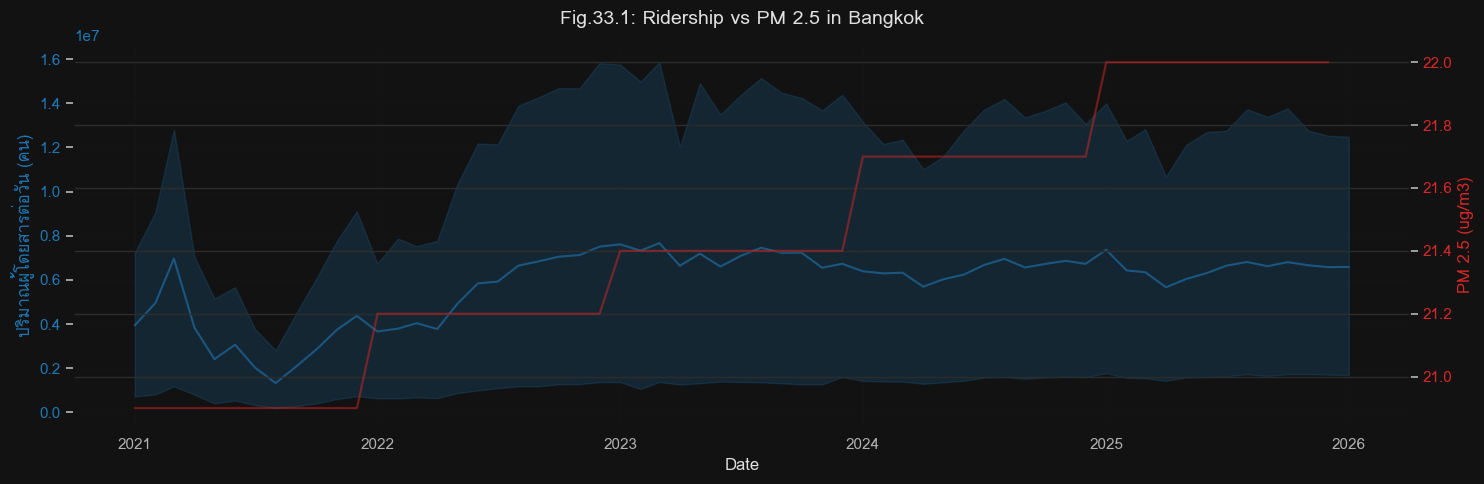

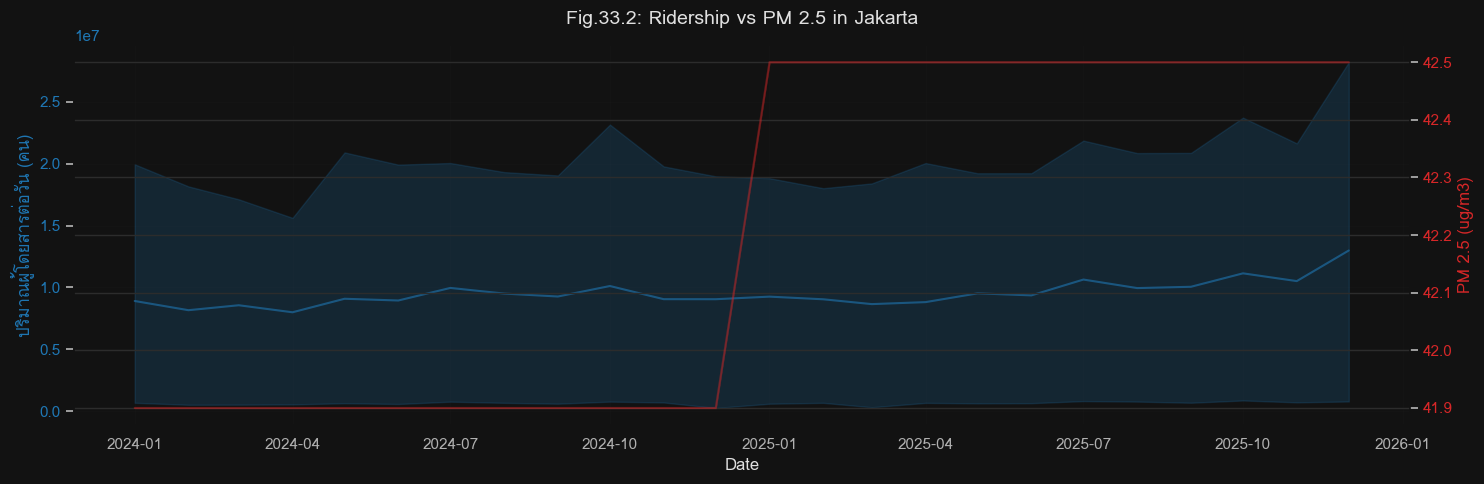

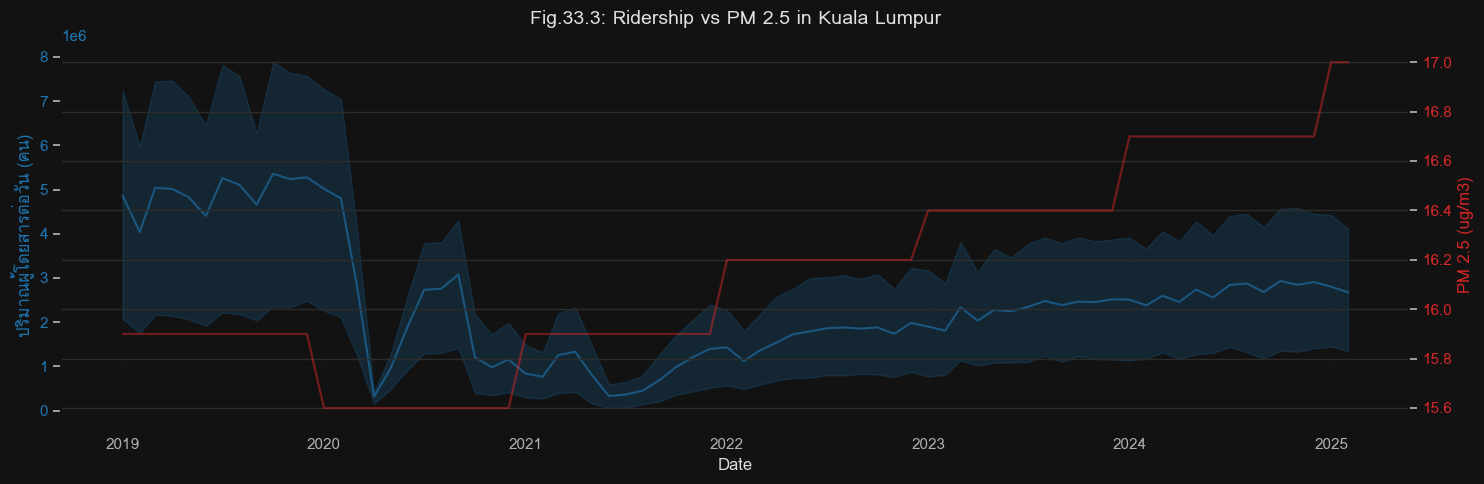

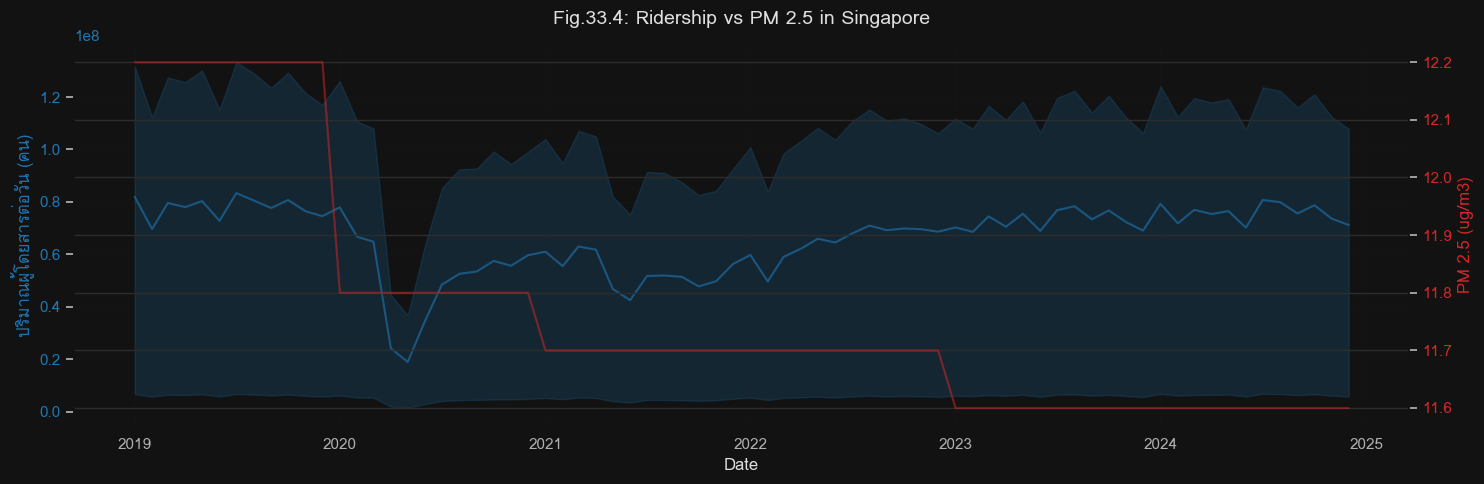

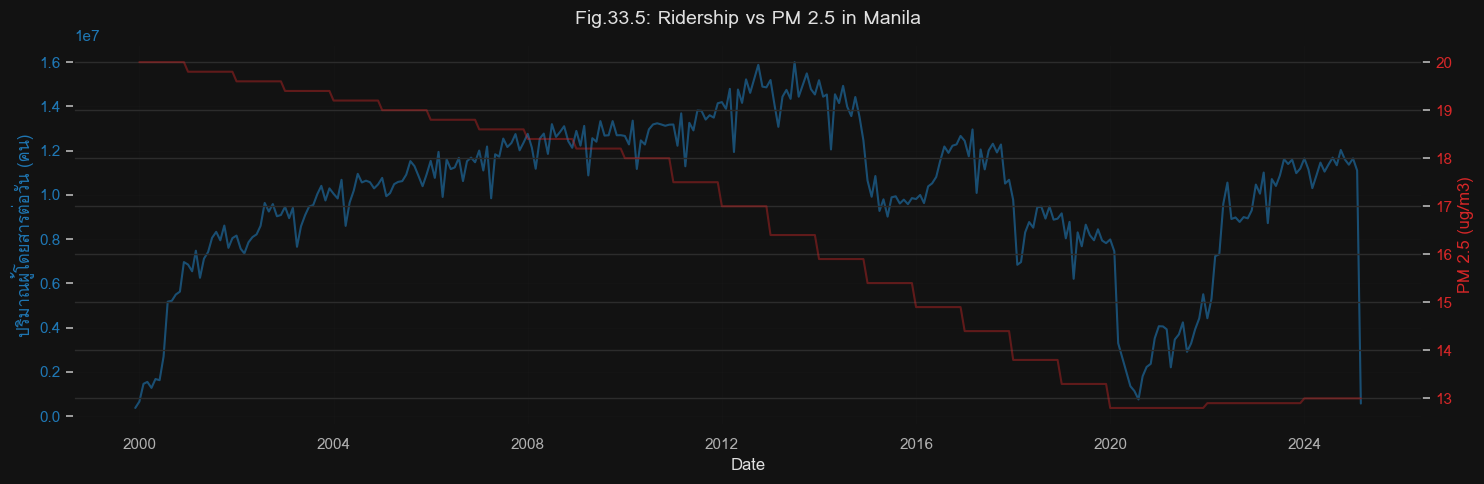

In [20]:
cities = df_active['City'].unique()

# ตั้งค่าสี
dark_grey = "#121212"
off_white = "#E0E0E0"
light_grey = "#B0B0B0"
grid_grey = "#2C2C2C"

plt.rcParams.update({
    "figure.facecolor": dark_grey,    # พื้นที่รอบนอกกราฟ
    "axes.facecolor": dark_grey,      # พื้นที่ในกราฟ
    "axes.edgecolor": dark_grey,      # ซ่อนขอบขาวโดยใช้สีเดียวกับพื้นหลัง
    "grid.color": grid_grey,          # เส้นตารางจางๆ
    "text.color": off_white,          # สีข้อความหลัก
    "axes.labelcolor": off_white,     # สีชื่อแกน
    "xtick.color": light_grey,        # สีตัวเลขแกน X
    "ytick.color": light_grey         # สีตัวเลขแกน Y
})

# loop เพื่อสร้างกราฟแต่ละเมือง
for i, city in enumerate(cities):
    # เปลี่ยนจาก daily_city_data เป็น df_active
    city_df = df_active[df_active['City'] == city].sort_values('Date')

    plt.figure(figsize=(15, 5))
    fig_label = f"Fig.33.{i+1}"

    ax1 = plt.gca()
    sns.lineplot(data=city_df, x='Date', y='Ridership', ax=ax1, color='#1f77b4', alpha=0.6)
    ax1.set_ylabel('ปริมาณผู้โดยสารต่อวัน (คน)', color='#1f77b4', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2 = ax1.twinx()
    sns.lineplot(data=city_df, x='Date', y='PM25_Mean_ug_m3', ax=ax2, color='#d62728', alpha=0.4)
    ax2.set_ylabel('PM 2.5 (ug/m3)', color='#d62728', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#d62728')

    plt.title(f'{fig_label}: Ridership vs PM 2.5 in {city}', fontsize=14, fontweight='bold', pad=15)

    ax1.grid(True, alpha=0.1)
    plt.tight_layout()
    plt.show()

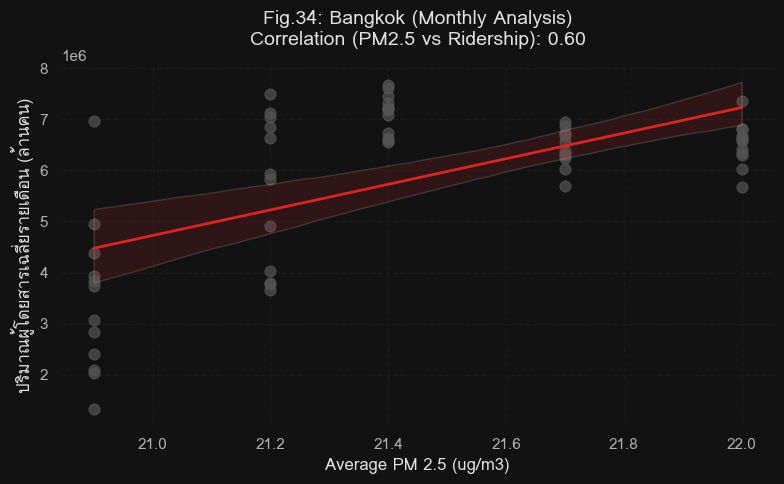

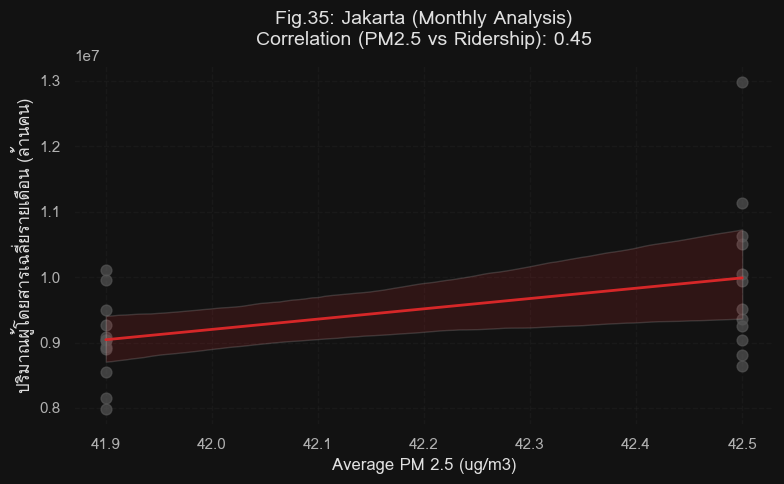

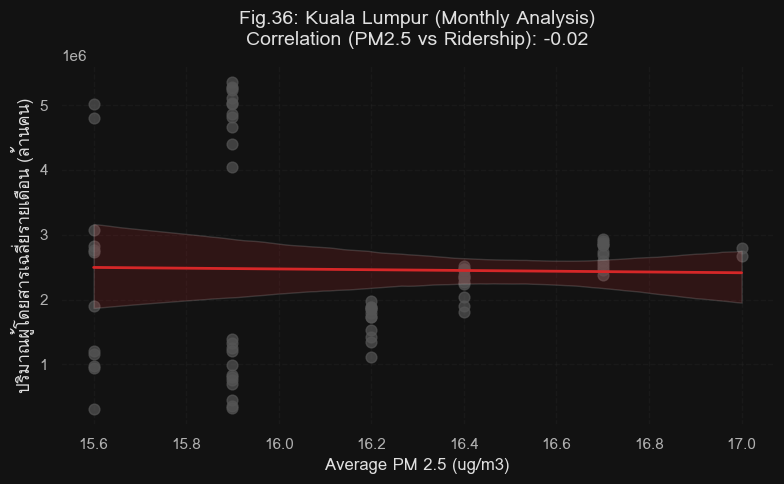

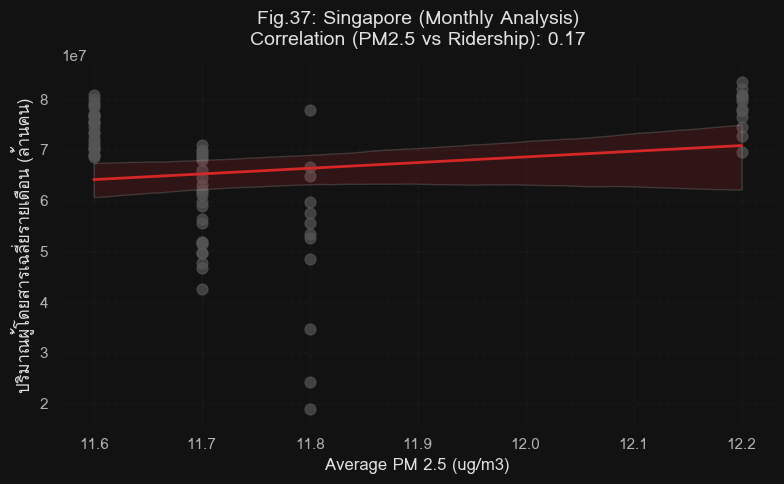

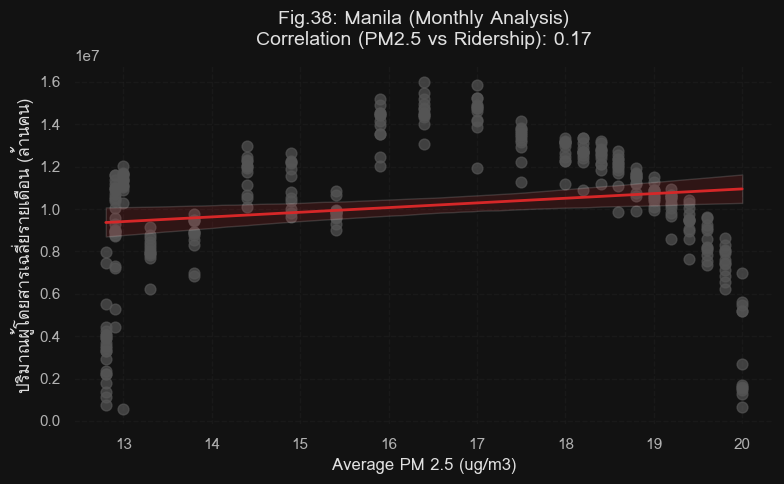

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# เตรียมข้อมูล
df = pd.read_csv("ASEAN_Urban_Growth_Final_with_Mode.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df_active = df[df['Ridership'] > 0].copy()

# ตั้งค่าการรันเลข Figure
fig_num = 34
unique_cities = df_active['City'].unique()

for city in unique_cities:

    city_df_daily = df_active[df_active['City'] == city].copy()

    city_df = city_df_daily.set_index('Date').resample('ME').mean(numeric_only=True).dropna().reset_index()

    # คำนวณ Correlation
    corr_val = city_df['PM25_Mean_ug_m3'].corr(city_df['Ridership'])

    # วาดกราฟ
    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=city_df,
        x="PM25_Mean_ug_m3",
        y="Ridership",
        scatter_kws={'alpha': 0.7, 's': 60, 'color': '#555555'},
        line_kws={'color': '#d62728', 'linewidth': 2}
    )

    # Title และ Label
    plt.title(f"Fig.{fig_num}: {city} (Monthly Analysis)\nCorrelation (PM2.5 vs Ridership): {corr_val:.2f}",
              fontweight='bold', color='#E0E0E0', fontsize=14, pad=15)

    plt.xlabel("Average PM 2.5 (ug/m3)")
    plt.ylabel("ปริมาณผู้โดยสารเฉลี่ยรายเดือน (ล้านคน)")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig_num += 1